In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# Define the path to the directory containing the compressed files
dataset_path = '/content/drive/My Drive/AIT/ML/citibike_project/dataset'

# Define the target directory for extraction
extraction_path = '/content/citibike_data'

# Create the target directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)
print(f"Target extraction directory '{extraction_path}' ensured.")

Target extraction directory '/content/citibike_data' ensured.


In [ ]:
print(f"Listing contents of '{dataset_path}':")
for item in os.listdir(dataset_path):
    if item.endswith('.zip'):
        zip_file_path = os.path.join(dataset_path, item)
        print(f"Extracting '{item}' to '{extraction_path}'...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extraction_path)
        print(f"Successfully extracted '{item}'.")

print(f"All compressed files extracted to '{extraction_path}'.")
print(f"Contents of extraction directory '{extraction_path}': {os.listdir(extraction_path)}")

Listing contents of '/content/drive/My Drive/AIT/ML/citibike_project/dataset':
Extracting 'JC-202512-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202512-citibike-tripdata.csv.zip'.
Extracting 'JC-202501-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202501-citibike-tripdata.csv.zip'.
Extracting 'JC-202502-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202502-citibike-tripdata.csv.zip'.
Extracting 'JC-202503-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202503-citibike-tripdata.csv.zip'.
Extracting 'JC-202504-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202504-citibike-tripdata.csv.zip'.
Extracting 'JC-202505-citibike-tripdata.csv.zip' to '/content/citibike_data'...
Successfully extracted 'JC-202505-citibike-tripdata.csv.zip'.
Extracting 'JC-202506-citibike-tripdata.csv.zip' to '/content/citibik

In [ ]:
import pandas as pd

# List all files within the extraction_path directory
all_files = os.listdir(extraction_path)

# Filter to include only .csv files
csv_files = [f for f in all_files if f.endswith('.csv')]

# Create an empty list to store the loaded DataFrames
dataframes = []

print(f"Found CSV files: {csv_files}")

# Iterate through the filtered list of CSV files and load them into DataFrames
for csv_file in csv_files:
    file_path = os.path.join(extraction_path, csv_file)
    print(f"Loading {csv_file}...")
    df = pd.read_csv(file_path)
    dataframes.append(df)
    print(f"Successfully loaded {csv_file} with {len(df)} rows and {len(df.columns)} columns.")

# Print the first 5 rows of each DataFrame
for i, df in enumerate(dataframes):
    print(f"\n--- Head of DataFrame {i+1} ({csv_files[i]}) ---")
    print(df.head())

Found CSV files: ['JC-202512-citibike-tripdata.csv', 'JC-202504-citibike-tripdata.csv', 'JC-202505-citibike-tripdata.csv', 'JC-202510-citibike-tripdata.csv', 'JC-202508-citibike-tripdata.csv', 'JC-202501-citibike-tripdata.csv', 'JC-202511-citibike-tripdata.csv', 'JC-202506-citibike-tripdata.csv', 'JC-202502-citibike-tripdata.csv', 'JC-202503-citibike-tripdata.csv', 'JC-202509-citibike-tripdata.csv', 'JC-202507-citibike-tripdata.csv']
Loading JC-202512-citibike-tripdata.csv...
Successfully loaded JC-202512-citibike-tripdata.csv with 48474 rows and 13 columns.
Loading JC-202504-citibike-tripdata.csv...
Successfully loaded JC-202504-citibike-tripdata.csv with 81553 rows and 13 columns.
Loading JC-202505-citibike-tripdata.csv...
Successfully loaded JC-202505-citibike-tripdata.csv with 93227 rows and 13 columns.
Loading JC-202510-citibike-tripdata.csv...
Successfully loaded JC-202510-citibike-tripdata.csv with 104205 rows and 13 columns.
Loading JC-202508-citibike-tripdata.csv...
Successful

In [ ]:
combined_df = pd.concat(dataframes, ignore_index=True)

print("--- Head of Combined DataFrame ---")
print(combined_df.head())

print(f"\nShape of combined_df: {combined_df.shape}")

--- Head of Combined DataFrame ---
            ride_id  rideable_type               started_at  \
0  FBA120ADE8D22E7D  electric_bike  2025-12-26 10:20:09.188   
1  DB8F52B8AE51DD28  electric_bike  2025-12-16 06:48:28.111   
2  C16D1CA1746E065F  electric_bike  2025-12-20 12:50:55.361   
3  7A613AF4BD6D75B9  electric_bike  2025-12-22 16:59:42.922   
4  2448F2B5B85E52B1  electric_bike  2025-12-17 18:06:09.352   

                  ended_at     start_station_name start_station_id  \
0  2025-12-26 10:40:13.508         Lafayette Park            JC078   
1  2025-12-16 06:56:10.969  Dr. Lena Edwards Park            JC117   
2  2025-12-20 12:58:32.234  Dr. Lena Edwards Park            JC117   
3  2025-12-22 17:04:29.327      JC Medical Center            JC110   
4  2025-12-17 18:14:13.548  Baldwin at Montgomery            JC020   

          end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  Vesey St & Greenwich St        5216.07  40.713464 -74.062859  40.712547   
1        

In [ ]:
print("--- Data Info (Data Types and Non-Null Counts) ---")
combined_df.info()

print("\n--- Missing Values Count ---")
print(combined_df.isnull().sum())

print("\n--- Descriptive Statistics for Numerical Columns ---")
print(combined_df.describe())

--- Data Info (Data Types and Non-Null Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002704 entries, 0 to 1002703
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   ride_id             1002704 non-null  object 
 1   rideable_type       1002704 non-null  object 
 2   started_at          1002704 non-null  object 
 3   ended_at            1002704 non-null  object 
 4   start_station_name  1002701 non-null  object 
 5   start_station_id    1002701 non-null  object 
 6   end_station_name    999469 non-null   object 
 7   end_station_id      998307 non-null   object 
 8   start_lat           1002702 non-null  float64
 9   start_lng           1002702 non-null  float64
 10  end_lat             999260 non-null   float64
 11  end_lng             999260 non-null   float64
 12  member_casual       1002704 non-null  object 
dtypes: float64(4), object(9)
memory usage: 99.5+ MB

--- Missing Value

**Step 1: Data Cleaning & Feature Extraction (The Basics)**

Before visualizing anything, you must clean the anomalies and create the features your model will need.

Datetime Conversion: Convert started_at and ended_at from strings (objects) to Pandas Datetime objects.

Calculate Trip Duration: Subtract started_at from ended_at to get the duration in minutes.

Filter Anomalies: Drop trips that are under 60 seconds (usually false starts or broken bikes) and trips over 24 hours (stolen/lost bikes).

Handle Missing Values: You have missing end_station_name and end_lat/end_lng. With e-bikes, riders sometimes lock them outside of official stations. Decide whether to drop these or categorize them as "Out of Station".

/tmp/ipython-input-3708268378.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['hour'] = clean_df['started_at'].dt.hour
/tmp/ipython-input-3708268378.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['day_of_week'] = clean_df['started_at'].dt.day_name()


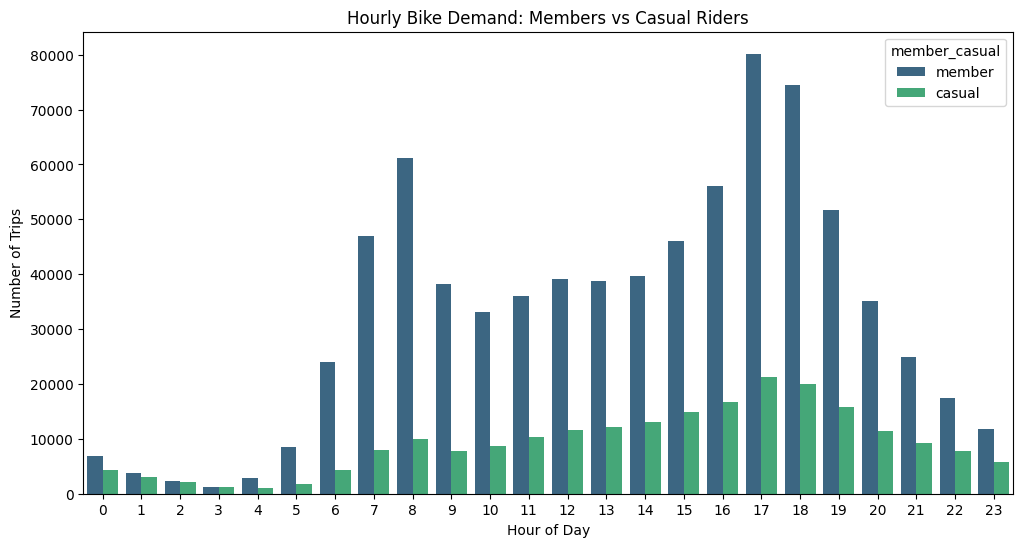

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert to Datetime
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'])
combined_df['ended_at'] = pd.to_datetime(combined_df['ended_at'])

# 2. Calculate Duration in Minutes
combined_df['duration_mins'] = (combined_df['ended_at'] - combined_df['started_at']).dt.total_seconds() / 60.0

# 3. Filter out bad data (e.g., negative times, fake starts)
clean_df = combined_df[(combined_df['duration_mins'] >= 1) & (combined_df['duration_mins'] <= 1440)]

# 4. Extract Time Features
clean_df['hour'] = clean_df['started_at'].dt.hour
clean_df['day_of_week'] = clean_df['started_at'].dt.day_name()

# 5. Plot Hourly Demand (Commuter vs Leisure)
plt.figure(figsize=(12, 6))
sns.countplot(data=clean_df, x='hour', hue='member_casual', palette='viridis')
plt.title('Hourly Bike Demand: Members vs Casual Riders')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.show()

The "Dockless E-Bike" Problem

Back in 2013 (your first dataset), every Citibike had to be locked into a physical physical dock. If you didn't, the timer kept running and you got charged. Therefore, almost every trip had a perfectly logged start_station and end_station.

By 2025, systems introduced hybrid e-bikes with built-in cable locks. Riders are often allowed to end their trip by locking the bike to a random street sign or public bike rack if the official station is full. When this happens, the system records the ended_at time, but the end_station_name registers as a NULL or missing value.

Why This Breaks Your Rebalancing Math
Your entire predictive model relies on the law of conservation of bikes:
Net Flow = Arrivals - Departures

If a rider takes a bike from Station A (Departure = 1) and locks it to a tree outside their apartment (Arrival at Station = NULL), you have a "leak" in your data. Station A lost a bike, but no other station gained one. If you don't clean this up, your model will eventually think thousands of bikes have just evaporated into thin air.

**Action**
If your project strictly focuses on rebalancing official physical stations, you should drop these rows entirely. You are telling the model, "Only look at trips that start and end at a valid dock."

In [ ]:
# Drop any trip that doesn't have a valid end station
clean_df = clean_df.dropna(subset=['end_station_name', 'end_lat', 'end_lng'])

emporal Analysis (Weekdays vs. Weekends)
Why we do this: In your current notebook, you plotted total hourly demand. However, a fleet operator’s strategy on a Tuesday at 8:00 AM (commuters) is completely different from a Saturday at 8:00 AM (leisure).

The Logic: We need to see if the "Bimodal peaks" (8 AM and 5 PM) disappear on weekends. If they do, your predictive model needs a "Day of the Week" feature to be accurate.

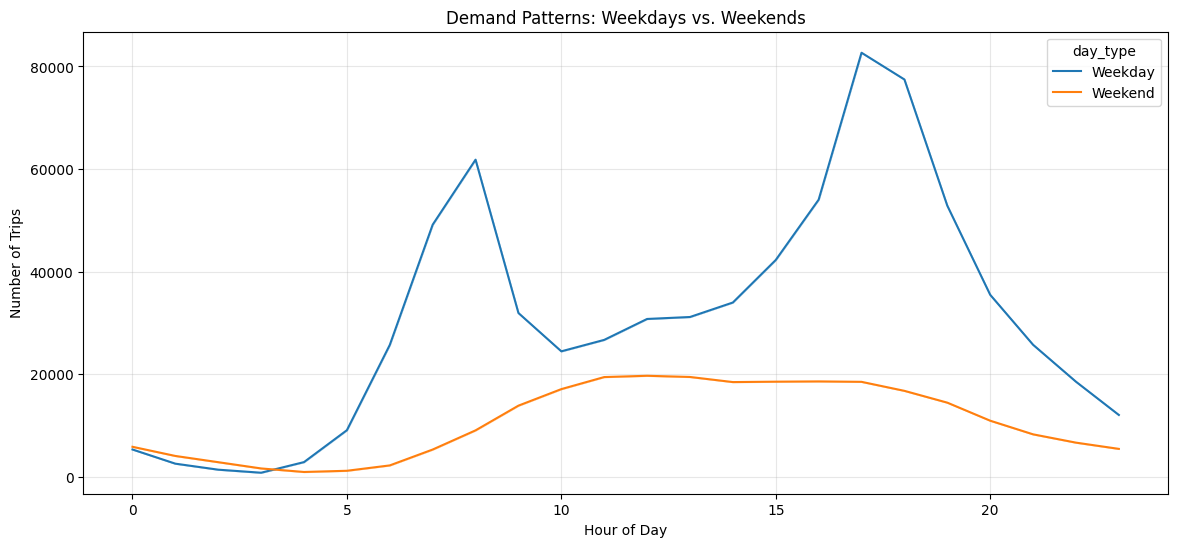

In [ ]:
# Add a flag for Weekend vs Weekday
clean_df['is_weekend'] = clean_df['started_at'].dt.dayofweek // 5 == 1
# Create a new column with descriptive string labels for the legend
clean_df['day_type'] = clean_df['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

# Plotting the comparison
plt.figure(figsize=(14, 6))
sns.lineplot(data=clean_df, x='hour', y='duration_mins', hue='day_type', estimator=len)
plt.title('Demand Patterns: Weekdays vs. Weekends')
plt.ylabel('Number of Trips')
plt.xlabel('Hour of Day')
# Let seaborn handle the legend automatically for consistent colors and labels
# plt.legend(title='Is Weekend?', labels=['Weekday', 'Weekend']) # Removed manual legend
plt.grid(True, alpha=0.3)
plt.show()

Spatial Popularity Analysis (Identifying Key Nodes)
Why we do this: Before we calculate "imbalance," we need to identify the "Main Arteries" of the city. These are the stations that handle the most traffic.

The Logic: We rank stations by total activity. This tells us which locations have the highest "turnover" and where rebalancing trucks will likely spend most of their time.

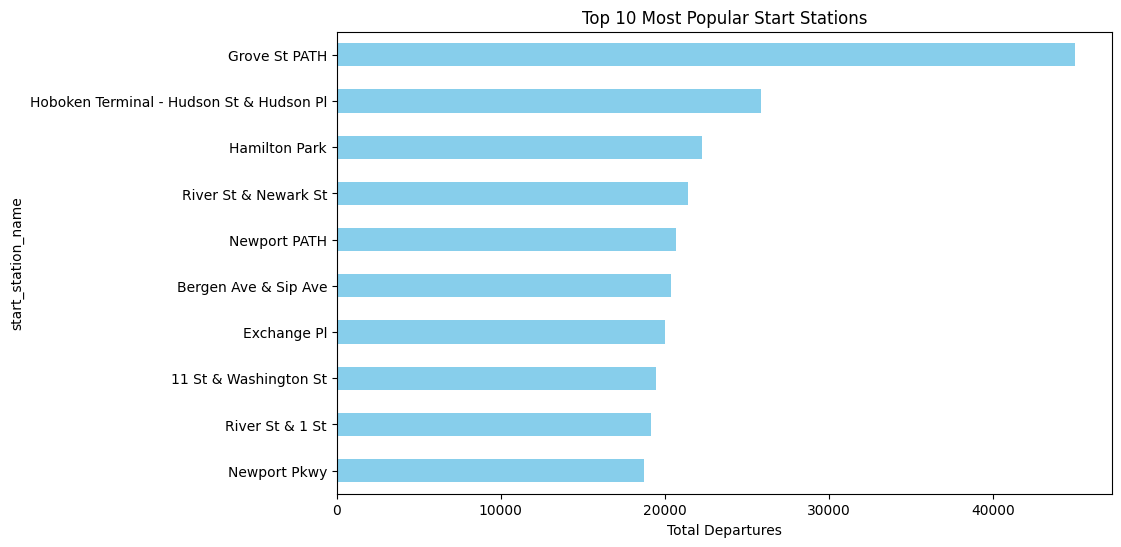

In [ ]:
# Identify the Top 10 most active stations
top_stations = clean_df['start_station_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_stations.plot(kind='barh', color='skyblue')
plt.title('Top 10 Most Popular Start Stations')
plt.xlabel('Total Departures')
plt.gca().invert_yaxis() # Highest on top
plt.show()

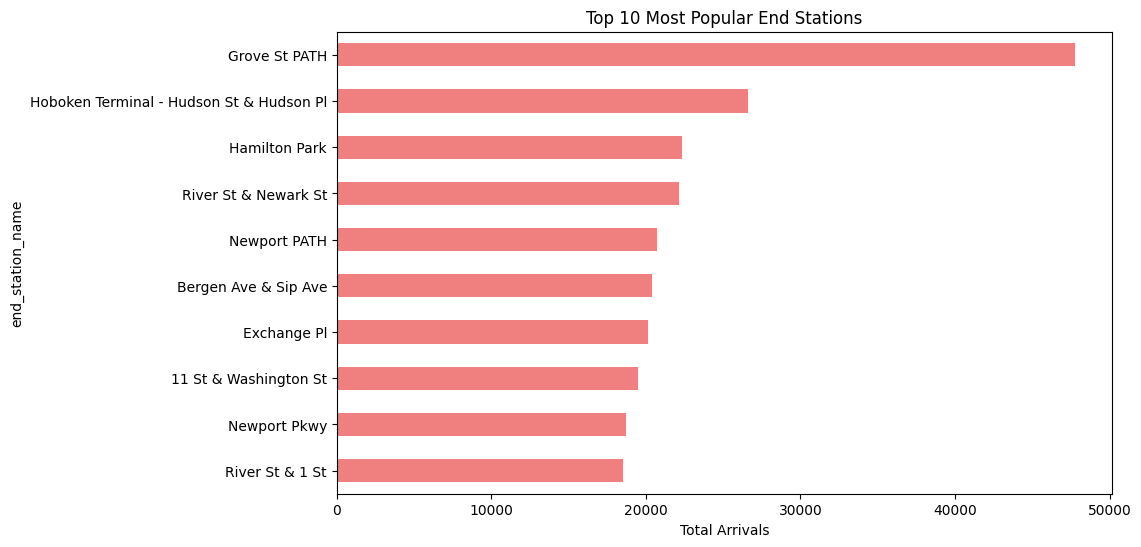

In [ ]:
# Identify the Top 10 most active end stations
top_end_stations = clean_df['end_station_name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_end_stations.plot(kind='barh', color='lightcoral')
plt.title('Top 10 Most Popular End Stations')
plt.xlabel('Total Arrivals')
plt.gca().invert_yaxis() # Highest on top
plt.show()

The Net Flow Aggregation (The Transformation)Why we do this: This is the most important part of your project. As we discussed, a rebalancing model doesn't care about "Trips"; it cares about "Inventory." We are transforming your 1-million-row trip list into a station-inventory summary.The Logic:Outflow: Count how many bikes left Station A at Hour 8.Inflow: Count how many bikes arrived at Station A at Hour 8.Net Demand: $\text{Inflow} - \text{Outflow}$.Positive: The station is a "Sink" (gaining bikes/filling up).Negative: The station is a "Source" (losing bikes/emptying).

In [ ]:
# --- STEP 4: MASTER NET FLOW AGGREGATION & COORDINATE MAPPING ---

# 1. Aggregate Outflows (Departures)
outflows = clean_df.groupby(['start_station_name', 'hour']).size().reset_index(name='outflow')
outflows.columns = ['station', 'hour', 'outflow']

# 2. Aggregate Inflows (Arrivals)
inflows = clean_df.groupby(['end_station_name', 'hour']).size().reset_index(name='inflow')
inflows.columns = ['station', 'hour', 'inflow']

# 3. Create the net_flow_df by merging Inflows and Outflows
net_flow_df = pd.merge(outflows, inflows, on=['station', 'hour'], how='outer').fillna(0)
net_flow_df['net_demand'] = net_flow_df['inflow'] - net_flow_df['outflow']

# 4. Create a ROBUST Coordinate Lookup (from both start and end stations)
start_coords = clean_df[['start_station_name', 'start_lat', 'start_lng']].rename(
    columns={'start_station_name': 'station', 'start_lat': 'lat', 'start_lng': 'lng'}
)
end_coords = clean_df[['end_station_name', 'end_lat', 'end_lng']].rename(
    columns={'end_station_name': 'station', 'end_lat': 'lat', 'end_lng': 'lng'}
)

# Combine and average to get one lat/lng per station name
coords_lookup = pd.concat([start_coords, end_coords]).dropna(subset=['station']).groupby('station')[['lat', 'lng']].mean().reset_index()

# 5. Merge the coordinates into our final dataframe
net_flow_df = pd.merge(net_flow_df, coords_lookup, on='station', how='left')

# Check the result
print("Net Flow Table successfully created!")
print(f"Total stations processed: {net_flow_df['station'].nunique()}")
display(net_flow_df.head())

Net Flow Table successfully created!
Total stations processed: 487


,station,hour,outflow,inflow,net_demand,lat,lng
0,1 Ave & E 38 St,8,0.0,1.0,1.0,40.746202,-73.971822
1,1 Ave & E 38 St,11,0.0,1.0,1.0,40.746202,-73.971822
2,1 Ave & E 6 St,10,0.0,1.0,1.0,40.726331,-73.986169
3,1 Ave & E 6 St,15,0.0,2.0,2.0,40.726331,-73.986169
4,1 Ave & E 6 St,16,0.0,1.0,1.0,40.726331,-73.986169


Visualizing the Imbalance (The Result)
Why we do this: Now that we have the net_demand, we can finally see the "pulse" of the city. This map proves your hypothesis: that bikes don't disappear randomly—they flow in predictable geographical directions.

The Logic: We use a Diverging Color Map (RdBu).

Red dots: Stations losing bikes (Operators need to bring bikes here).

Blue dots: Stations gaining bikes (Operators need to remove bikes here).

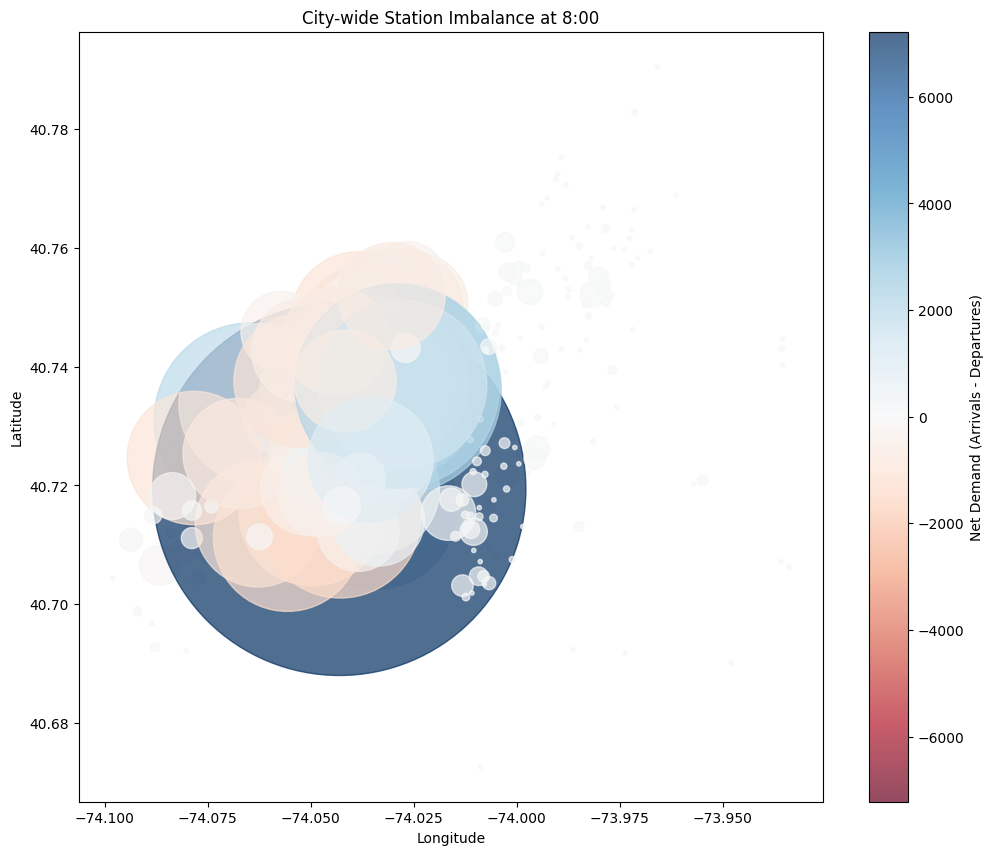

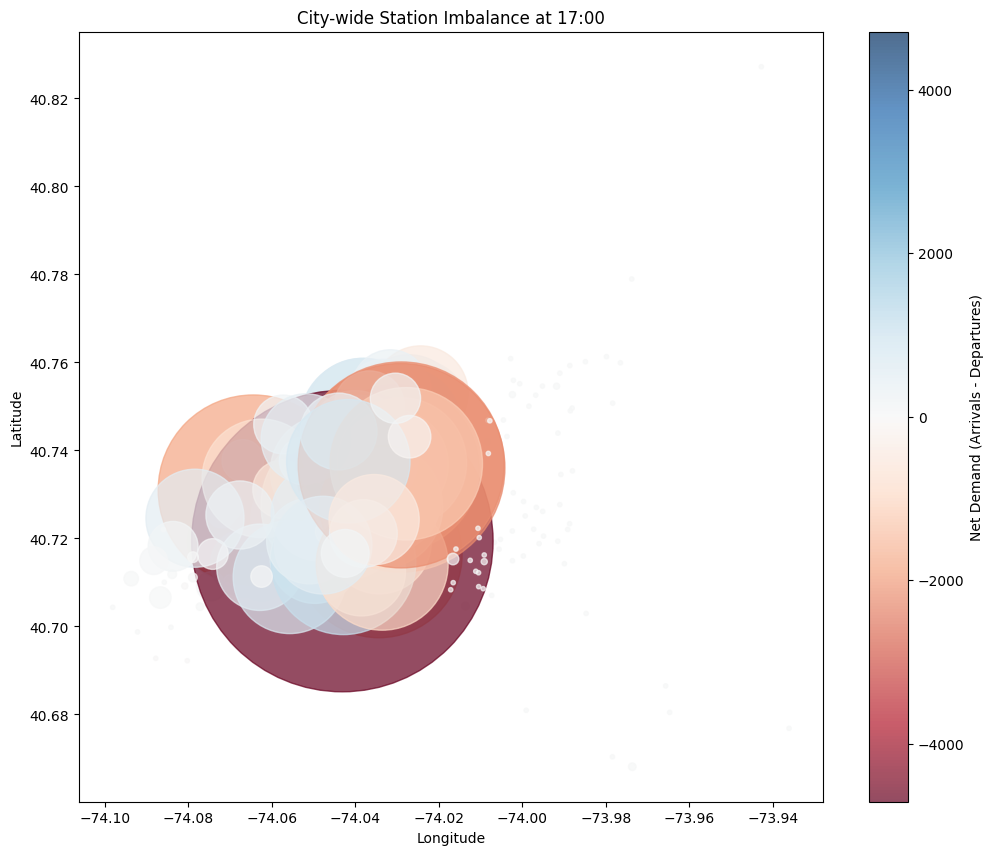

In [ ]:
def plot_city_imbalance(target_hour):
    # Filter for the specific hour (e.g., 8 AM Rush)
    hour_data = net_flow_df[net_flow_df['hour'] == target_hour]

    plt.figure(figsize=(12, 10))

    # We use a scatter plot where the color is the demand
    # vmin and vmax ensure 0 is the 'white' center of the color scale
    limit = max(abs(hour_data['net_demand'].min()), abs(hour_data['net_demand'].max()))

    scatter = plt.scatter(
        hour_data['lng'],
        hour_data['lat'],
        c=hour_data['net_demand'],
        cmap='RdBu',
        s=abs(hour_data['net_demand']) * 10, # Size proportional to imbalance
        alpha=0.7,
        vmin=-limit,
        vmax=limit
    )

    plt.colorbar(scatter, label='Net Demand (Arrivals - Departures)')
    plt.title(f'City-wide Station Imbalance at {target_hour}:00')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()

# Visualize the 8 AM Morning Commute
plot_city_imbalance(8)

# Visualize the 5 PM Evening Commute
plot_city_imbalance(17)

The "Ghost Station" Check
Why: Modern datasets often include "administrative" stations used for maintenance, testing, or bike storage. These aren't real locations where users can pick up bikes. If you include them, your model will waste energy trying to predict demand for a "station" that is actually just a repair van or a warehouse.

The Logic: We search for keywords like "test," "workshop," "charging," or "DOT" (Department of Transportation) in the station names. We also flag stations with extremely low activity (e.g., only 1 or 2 trips for the whole month), as these are often temporary or non-functional nodes.

In [ ]:
# 1. Look for suspicious keywords in station names
keywords = ['test', 'workshop', 'maintenance', 'dot', 'charging', 'check', 'hub', 'warehouse']
ghost_mask = clean_df['start_station_name'].str.contains('|'.join(keywords), case=False, na=False)
ghost_stations = clean_df[ghost_mask]['start_station_name'].unique()

print("--- Potential Ghost Stations Identified ---")
print(ghost_stations)

# 2. Check for extremely low activity stations (e.g., < 5 trips per month)
station_activity = clean_df['start_station_name'].value_counts()
low_activity_stations = station_activity[station_activity < 5].index.tolist()

print(f"\n--- Low Activity Stations (<5 trips): {len(low_activity_stations)} stations ---")
# You can uncomment the line below to see them all
# print(low_activity_stations)

# 3. Decision: Filter them out to keep your data clean
stations_to_remove = set(list(ghost_stations) + low_activity_stations)
clean_df = clean_df[~clean_df['start_station_name'].isin(stations_to_remove)]
clean_df = clean_df[~clean_df['end_station_name'].isin(stations_to_remove)]

print(f"\nCleaned! Removed {len(stations_to_remove)} administrative or low-activity stations.")

--- Potential Ghost Stations Identified ---
[]

--- Low Activity Stations (<5 trips): 1 stations ---

Cleaned! Removed 1 administrative or low-activity stations.


Seasonality and Trends (The "City Heartbeat")
Why: Machine Learning models for rebalancing are essentially "pattern matchers." For a model to work, the demand must have a repeating structure (Seasonality).

The Logic: We plot the total number of trips across the entire city for every hour of every day. If the resulting graph looks like a "heartbeat" (a consistent wave that repeats every 24 hours), it confirms that the human behavior in your dataset is predictable enough for a computer to learn.

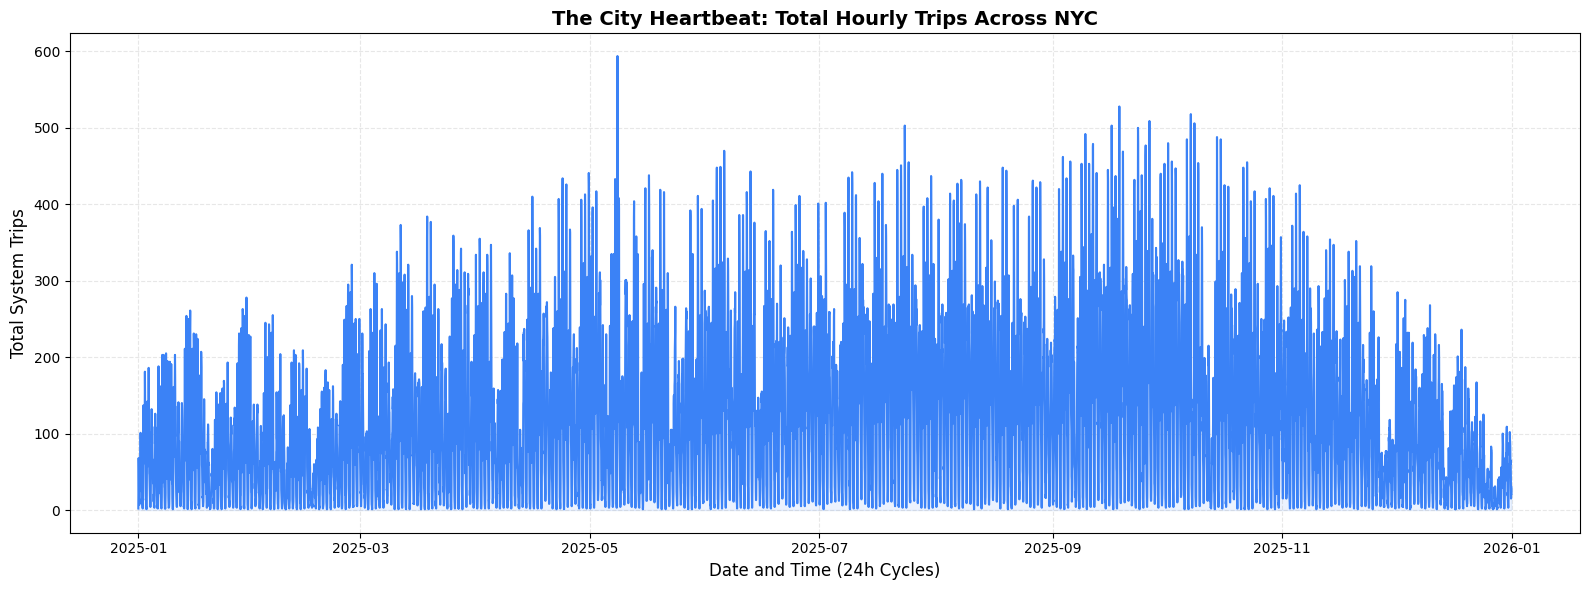

In [ ]:
# 1. Create a timestamp for every hour of the month
# We group by date and hour to see the full timeline
heartbeat_df = clean_df.groupby([clean_df['started_at'].dt.date, 'hour']).size().reset_index(name='trip_count')

# Combine date and hour back into a single datetime for plotting
heartbeat_df['timestamp'] = pd.to_datetime(heartbeat_df['started_at'].astype(str) + ' ' + heartbeat_df['hour'].astype(str) + ':00:00')

# 2. Plot the Heartbeat
plt.figure(figsize=(16, 6))
plt.plot(heartbeat_df['timestamp'], heartbeat_df['trip_count'], color='#3b82f6', linewidth=1.5)

# Highlight the peaks (Rush Hours)
plt.fill_between(heartbeat_df['timestamp'], heartbeat_df['trip_count'], color='#3b82f6', alpha=0.1)

plt.title('The City Heartbeat: Total Hourly Trips Across NYC', fontsize=14, fontweight='bold')
plt.xlabel('Date and Time (24h Cycles)', fontsize=12)
plt.ylabel('Total System Trips', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Missing Values Count ---")
print(clean_df.head())


--- Missing Values Count ---
            ride_id  rideable_type              started_at  \
0  FBA120ADE8D22E7D  electric_bike 2025-12-26 10:20:09.188   
1  DB8F52B8AE51DD28  electric_bike 2025-12-16 06:48:28.111   
2  C16D1CA1746E065F  electric_bike 2025-12-20 12:50:55.361   
3  7A613AF4BD6D75B9  electric_bike 2025-12-22 16:59:42.922   
4  2448F2B5B85E52B1  electric_bike 2025-12-17 18:06:09.352   

                 ended_at     start_station_name start_station_id  \
0 2025-12-26 10:40:13.508         Lafayette Park            JC078   
1 2025-12-16 06:56:10.969  Dr. Lena Edwards Park            JC117   
2 2025-12-20 12:58:32.234  Dr. Lena Edwards Park            JC117   
3 2025-12-22 17:04:29.327      JC Medical Center            JC110   
4 2025-12-17 18:14:13.548  Baldwin at Montgomery            JC020   

          end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  Vesey St & Greenwich St        5216.07  40.713464 -74.062859  40.712547   
1              Exchange Pl

# Feature Engineering

*   Cyclical Encoding (Hour & Day): Computers don't naturally know that 11 PM (hour 23) is right next to 12 AM (hour 0). By using Sine and Cosine transformations, we represent time as a circle ⭕ rather than a straight line.
*   Lag Features ($T-n$): The best predictor of what will happen in an hour is often what happened an hour ago or exactly 24 hours ago. These features give the model "memory" 🧠.


*   Re-indexing: This is the most critical technical step. By re-indexing, we ensure that the "memory" of our model is never broken. If a station was empty at 3 AM and stayed empty at 4 AM, the model needs to see that "0" flow to understand the pattern, rather than having the 4 AM data missing entirely.





In [ ]:
import pandas as pd
import numpy as np

# --- 1. PREPARING THE COMPLETE TIME-SERIES GRID (RE-INDEXING) ---
# We need a row for every station, every day, and every hour to make lags accurate.

# Get unique stations and the date range from your clean_df
stations = net_flow_df['station'].unique()
dates = pd.to_datetime(clean_df['started_at']).dt.date.unique()
hours = range(24)

# Create a MultiIndex of all combinations (Product of Stations x Dates x Hours)
multi_index = pd.MultiIndex.from_product(
    [stations, dates, hours],
    names=['station', 'date', 'hour']
)

# Create the master grid
feature_df = pd.DataFrame(index=multi_index).reset_index()
feature_df['date'] = pd.to_datetime(feature_df['date'])

# Merge with your existing net_flow_df (from your previous EDA work)
# Note: Ensure net_flow_df has a 'date' column extracted from started_at
if 'date' not in net_flow_df.columns:
    # Assuming net_flow_df was built from clean_df
    # We add date back to net_flow_df if it's missing
    # This assumes we are working with the hourly aggregated data
    pass

# Merging current net_flow data into the grid
# Fill NaNs with 0 (No activity = 0 demand)
final_df = pd.merge(
    feature_df,
    net_flow_df[['station', 'hour', 'net_demand', 'lat', 'lng']],
    on=['station', 'hour'],
    how='left'
).fillna({'net_demand': 0})

# Fill Lat/Lng for the newly created empty rows using the lookup we built in EDA
final_df = final_df.drop(columns=['lat', 'lng']).merge(coords_lookup, on='station', how='left')

# --- 2. CYCLICAL TIME ENCODING ---
# Convert hour (0-23) into Sine and Cosine to represent the circular nature of time
final_df['hour_sin'] = np.sin(2 * np.pi * final_df['hour'] / 24)
final_df['hour_cos'] = np.cos(2 * np.pi * final_df['hour'] / 24)

# Day of week encoding (0=Monday, 6=Sunday)
final_df['day_of_week'] = final_df['date'].dt.dayofweek
final_df['day_sin'] = np.sin(2 * np.pi * final_df['day_of_week'] / 7)
final_df['day_cos'] = np.cos(2 * np.pi * final_df['day_of_week'] / 7)

# --- 3. MULTI-SCALE LAG FEATURES ---
# Sort by station and time to ensure shift() works correctly
final_df = final_df.sort_values(['station', 'date', 'hour'])

# Create Lags (T-1, T-2, T-3, T-24)
lags = [1, 2, 3, 24]
for lag in lags:
    final_df[f'lag_{lag}h'] = final_df.groupby('station')['net_demand'].shift(lag)

# --- 4. ROLLING WINDOW STATISTICS ---
# 3-hour moving average of demand
final_df['rolling_mean_3h'] = final_df.groupby('station')['net_demand'].transform(
    lambda x: x.shift(1).rolling(window=3).mean()
)

# --- 5. CLEANUP ---
# Drop the first 24 hours of data for each station because they won't have complete lag features
final_df = final_df.dropna()

print("Feature Engineering Complete!")
print(f"Final dataset shape: {final_df.shape}")
print("\nNew Features Created:")
print(final_df[['station', 'hour', 'net_demand', 'hour_sin', 'hour_cos', 'lag_1h', 'lag_24h']].head())

Feature Engineering Complete!
Final dataset shape: (4266120, 16)

New Features Created:
              station  hour  net_demand  hour_sin  hour_cos  lag_1h  lag_24h
3960  1 Ave & E 38 St     0         0.0  0.000000  1.000000     0.0      0.0
3961  1 Ave & E 38 St     1         0.0  0.258819  0.965926     0.0      0.0
3962  1 Ave & E 38 St     2         0.0  0.500000  0.866025     0.0      0.0
3963  1 Ave & E 38 St     3         0.0  0.707107  0.707107     0.0      0.0
3964  1 Ave & E 38 St     4         0.0  0.866025  0.500000     0.0      0.0


Saving the final cleaned dataset and visualization of entire dataset.

In [ ]:
# 1. Save the final dataset to a CSV file (this might take a minute or two!)
file_name = "micro_mobility_training_data_2025.csv"
final_df.to_csv(file_name, index=False)
print(f"💾 Dataset successfully saved as: {file_name}")

# 2. Comprehensive Data Inspection
print("\n--- 📊 Dataset Info ---")
# .info() shows column types and checks for any lingering missing values
final_df.info()

print("\n--- 📈 Statistical Summary ---")
# .describe() shows the mean, min, max, and distribution of your numerical features
display(final_df.describe())

print("\n--- 🎲 Random Sample of 10 Rows ---")
# .sample() gives a much better feel for the data than .head() by picking random rows from anywhere
display(final_df.sample(10))

print("\n--- 🏁 The Last 5 Rows ---")
# .tail() shows the very end of your time-series
display(final_df.tail())

💾 Dataset successfully saved as: micro_mobility_training_data_2025.csv

--- 📊 Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4266120 entries, 3960 to 4269503
Data columns (total 16 columns):
 #   Column           Dtype         
---  ------           -----         
 0   station          object        
 1   date             datetime64[ns]
 2   hour             int64         
 3   net_demand       float64       
 4   lat              float64       
 5   lng              float64       
 6   hour_sin         float64       
 7   hour_cos         float64       
 8   day_of_week      int32         
 9   day_sin          float64       
 10  day_cos          float64       
 11  lag_1h           float64       
 12  lag_2h           float64       
 13  lag_3h           float64       
 14  lag_24h          float64       
 15  rolling_mean_3h  float64       
dtypes: datetime64[ns](1), float64(12), int32(1), int64(1), object(1)
memory usage: 537.0+ MB

--- 📈 Statistical Summary ---


,date,hour,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h
count,4266120,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06,4.266120e+06
mean,2025-07-02 00:00:00,1.150000e+01,2.566735e-04,4.073398e+01,-7.400139e+01,-1.850549e-17,-5.551188e-17,2.997260e+00,2.671035e-03,-6.096464e-04,2.566735e-04,2.566735e-04,2.566735e-04,2.566735e-04,2.566735e-04
min,2025-01-01 00:00:00,0.000000e+00,-4.711000e+03,4.064915e+01,-7.409811e+01,-1.000000e+00,-1.000000e+00,0.000000e+00,-9.749279e-01,-9.009689e-01,-4.711000e+03,-4.711000e+03,-4.711000e+03,-4.711000e+03,-3.982333e+03
25%,2025-04-02 00:00:00,5.750000e+00,0.000000e+00,4.071495e+01,-7.401362e+01,-7.071068e-01,-7.071068e-01,1.000000e+00,-7.818315e-01,-9.009689e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2025-07-02 00:00:00,1.150000e+01,0.000000e+00,4.073117e+01,-7.399609e+01,6.123234e-17,-6.123234e-17,3.000000e+00,0.000000e+00,-2.225209e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2025-10-01 00:00:00,1.725000e+01,0.000000e+00,4.075173e+01,-7.398128e+01,7.071068e-01,7.071068e-01,5.000000e+00,7.818315e-01,6.234898e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.333333e-01
max,2025-12-31 00:00:00,2.300000e+01,7.220000e+03,4.088630e+01,-7.388781e+01,1.000000e+00,1.000000e+00,6.000000e+00,9.749279e-01,1.000000e+00,7.220000e+03,7.220000e+03,7.220000e+03,7.220000e+03,5.250000e+03
std,NaN,6.922187e+00,1.845026e+02,3.063249e-02,3.530768e-02,7.071069e-01,7.071069e-01,1.997943e+00,7.079740e-01,7.062333e-01,1.845026e+02,1.845026e+02,1.845026e+02,1.845026e+02,1.654804e+02



--- 🎲 Random Sample of 10 Rows ---


,station,date,hour,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h
3808115,W 47 St & 6 Ave,2025-11-08,11,0.0,40.758154,-73.981957,0.258819,-0.965926,5,-0.974928,-0.222521,0.0,0.0,1.0,0.0,0.333333
570521,Atlantic Ave & Fort Greene Pl,2025-07-02,17,0.0,40.683826,-73.976323,-0.965926,-0.258819,2,0.974928,-0.222521,0.0,0.0,0.0,0.0,0.000000
930689,Cadman Plaza E & Tillary St,2025-07-08,17,0.0,40.695977,-73.990149,-0.965926,-0.258819,1,0.781831,0.623490,0.0,0.0,0.0,0.0,0.000000
558572,Astor Place,2025-11-22,20,342.0,40.719282,-74.071262,-0.866025,0.500000,5,-0.974928,-0.222521,301.0,395.0,293.0,342.0,329.666667
3226,1 Ave & E 38 St,2025-08-08,10,0.0,40.746202,-73.971822,0.500000,-0.866025,4,-0.433884,-0.900969,0.0,1.0,0.0,0.0,0.333333
2185304,JC Medical Center,2025-03-03,8,-1106.0,40.715391,-74.049692,0.866025,-0.500000,0,0.000000,1.000000,-562.0,142.0,-1.0,-1106.0,-140.333333
986036,Central Park S & Grand Army Plaza,2025-05-26,20,0.0,40.764555,-73.973473,-0.866025,0.500000,0,0.000000,1.000000,0.0,0.0,0.0,0.0,0.000000
3589095,W 27 St & 6 Ave,2025-11-09,15,0.0,40.745260,-73.990620,-0.707107,-0.707107,6,-0.781831,0.623490,0.0,0.0,0.0,0.0,0.000000
2345781,Lexington Ave & E 36 St,2025-12-04,21,0.0,40.747574,-73.978801,-0.707107,0.707107,3,0.433884,-0.900969,0.0,0.0,0.0,0.0,0.000000
2906137,Park Ave & E 42 St,2025-09-06,1,0.0,40.751873,-73.977706,0.258819,0.965926,5,-0.974928,-0.222521,0.0,0.0,0.0,0.0,0.000000



--- 🏁 The Last 5 Rows ---


,station,date,hour,net_demand,lat,lng,hour_sin,hour_cos,day_of_week,day_sin,day_cos,lag_1h,lag_2h,lag_3h,lag_24h,rolling_mean_3h
4269499,York St & Marin Blvd,2025-12-31,19,63.0,40.716615,-74.042412,-0.965926,0.258819,2,0.974928,-0.222521,147.0,119.0,54.0,63.0,106.666667
4269500,York St & Marin Blvd,2025-12-31,20,-67.0,40.716615,-74.042412,-0.866025,0.500000,2,0.974928,-0.222521,63.0,147.0,119.0,-67.0,109.666667
4269501,York St & Marin Blvd,2025-12-31,21,-29.0,40.716615,-74.042412,-0.707107,0.707107,2,0.974928,-0.222521,-67.0,63.0,147.0,-29.0,47.666667
4269502,York St & Marin Blvd,2025-12-31,22,-35.0,40.716615,-74.042412,-0.500000,0.866025,2,0.974928,-0.222521,-29.0,-67.0,63.0,-35.0,-11.000000
4269503,York St & Marin Blvd,2025-12-31,23,-28.0,40.716615,-74.042412,-0.258819,0.965926,2,0.974928,-0.222521,-35.0,-29.0,-67.0,-28.0,-43.666667


In [23]:
print(f"Number of unique stations in final_df: {final_df['station'].nunique()}")

Number of unique stations in final_df: 487
